In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\harsh\Documents\customer-churn-prediction\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

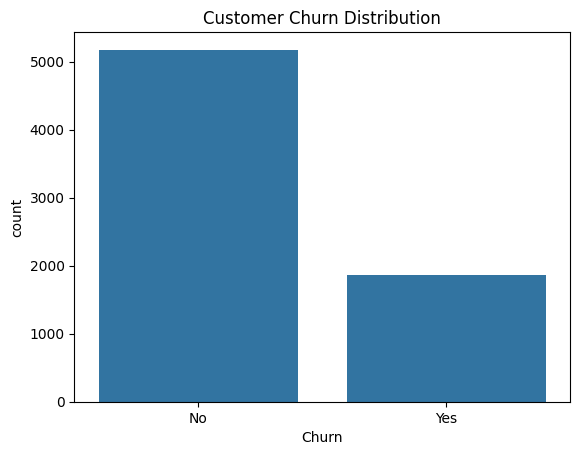

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x = 'Churn', data = df)
plt.title("Customer Churn Distribution")
plt.show()

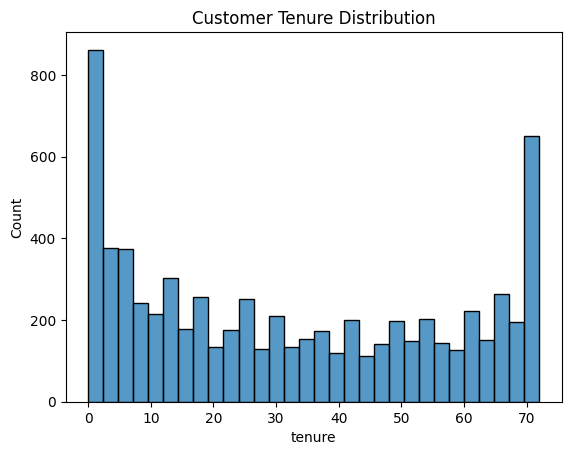

In [8]:
sns.histplot(df['tenure'], bins = 30)
plt.title("Customer Tenure Distribution")
plt.show()

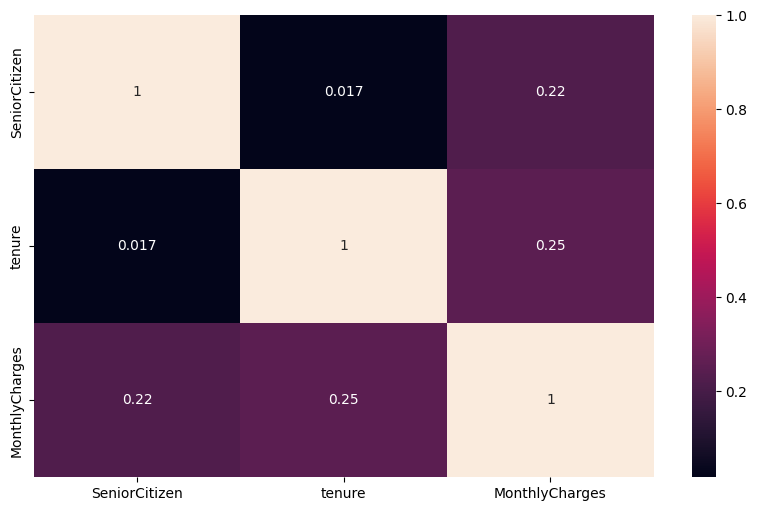

In [9]:
numeric_df = df.select_dtypes(include = ['number'])
plt.figure(figsize = (10,6))
sns.heatmap(numeric_df.corr(), annot = True)
plt.show()

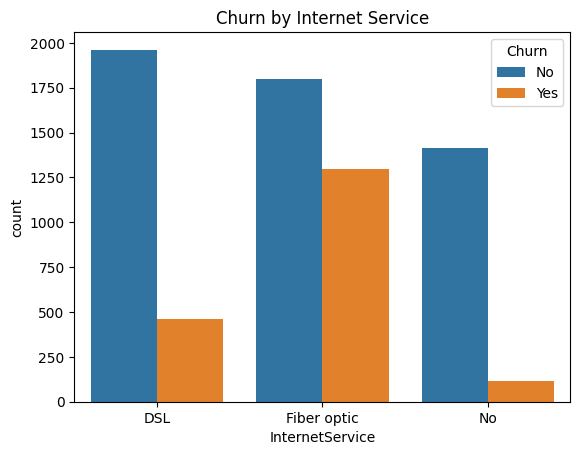

In [16]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")
plt.show()

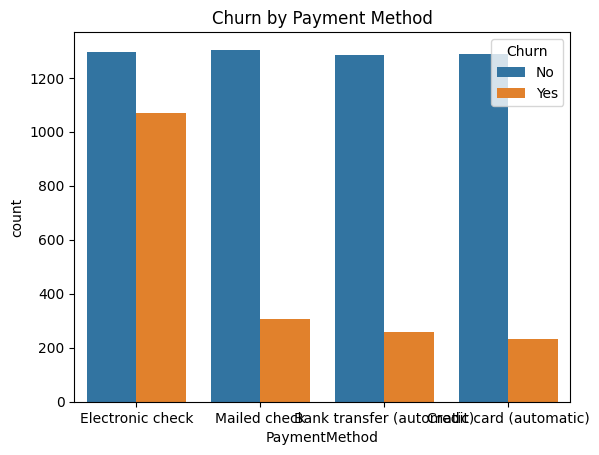

In [15]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Churn by Payment Method")
plt.show()

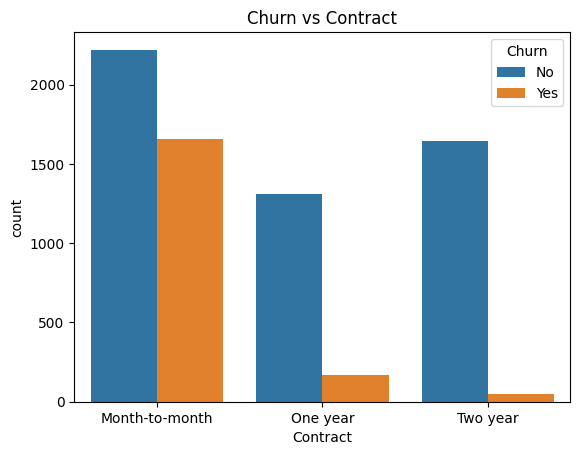

In [17]:
sns.countplot(x="Contract", hue = "Churn", data = df)
plt.title("Churn vs Contract")
plt.show()

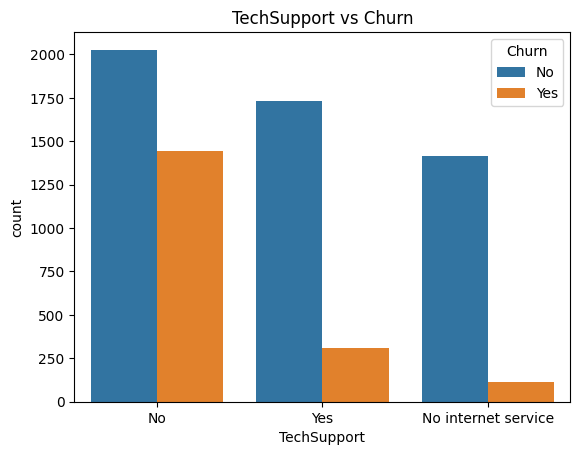

In [19]:
sns.countplot(x = "TechSupport", hue = "Churn", data = df)
plt.title("TechSupport vs Churn")
plt.show()

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

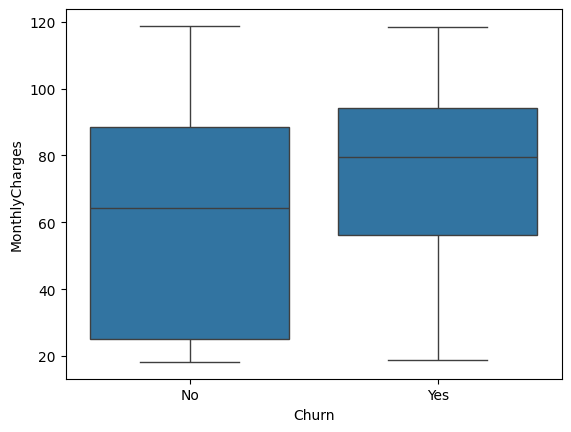

In [12]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

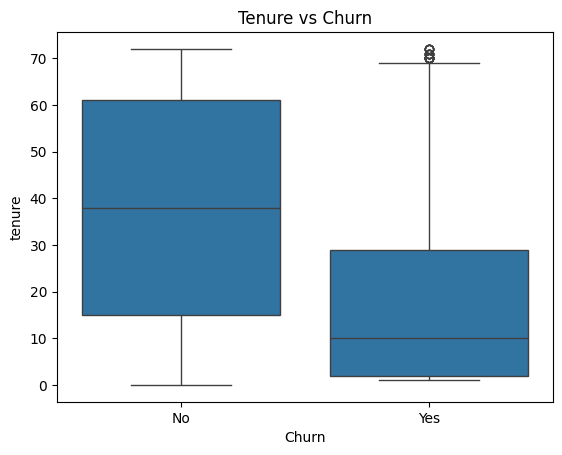

In [13]:
sns.boxplot(x = "Churn" , y = "tenure", data = df)
plt.title("Tenure vs Churn")
plt.show()

## Summary of Exploratory Data Analysis

* The dataset contains 7043 telecom customers with 21 features related to demographics, services, and account information.
* The target variable **Churn** indicates whether a customer has left the service.

### Key Findings:

* Customers with **lower tenure** are more likely to churn, indicating that new customers are at higher risk.
* Customers with **higher monthly charges** tend to churn more compared to those with lower charges.
* The correlation heatmap shows **weak relationships among numerical features**, suggesting they provide independent information.
* Categorical features such as **Contract type, Internet Service, Payment Method, and Tech Support** are expected to have a strong influence on churn behavior.

### Conclusion:

* Both **customer tenure and pricing (monthly charges)** are important factors influencing churn.
* Further analysis of categorical features will help identify the strongest drivers of churn.


## Data Preprocessing

In [21]:
df.drop("customerID", axis = 1, inplace = True)

In [23]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"] , errors = "coerce")

In [24]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [25]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace = True)

C:\Users\harsh\AppData\Local\Temp\ipykernel_11924\3328430945.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace = True)


In [26]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [27]:
df = pd.get_dummies(df, drop_first = True)

In [29]:
X = df.drop("Churn", axis = 1)
y = df["Churn"]

# Train-test Split

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Data Preprocessing

- Removed unnecessary columns such as customerID
- Converted TotalCharges to numeric and handled missing values
- Encoded categorical variables using one-hot encoding
- Converted target variable (Churn) into binary format
- Split data into training and testing sets

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [34]:
log_model = LogisticRegression(max_iter = 1000)
log_model.fit(X_train, y_train)

C:\Users\harsh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [35]:
y_pred_log = log_model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Accuracy: 0.8211497515968772

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409


Confusion Matrix:
 [[933 103]
 [149 224]]
